In [7]:
# ノードで試行したい　こっからが僕だよ
# ノード数少なくして
from src.make_map_list import make_map

num_node = 7
map = make_map(num_node)
print(map)

{'0': {'pos': (58, 86), 'edges': [('5', 62), ('1', 20)]}, '1': {'pos': (41, 98), 'edges': [('2', 38), ('5', 79)]}, '2': {'pos': (74, 79), 'edges': [('5', 53), ('3', 75)]}, '3': {'pos': (35, 14), 'edges': [('4', 72), ('6', 79)]}, '4': {'pos': (34, 86), 'edges': [('5', 72), ('1', 13)]}, '5': {'pos': (74, 26), 'edges': [('4', 72), ('0', 62)]}, '6': {'pos': (51, 92), 'edges': [('5', 69), ('2', 26)]}}


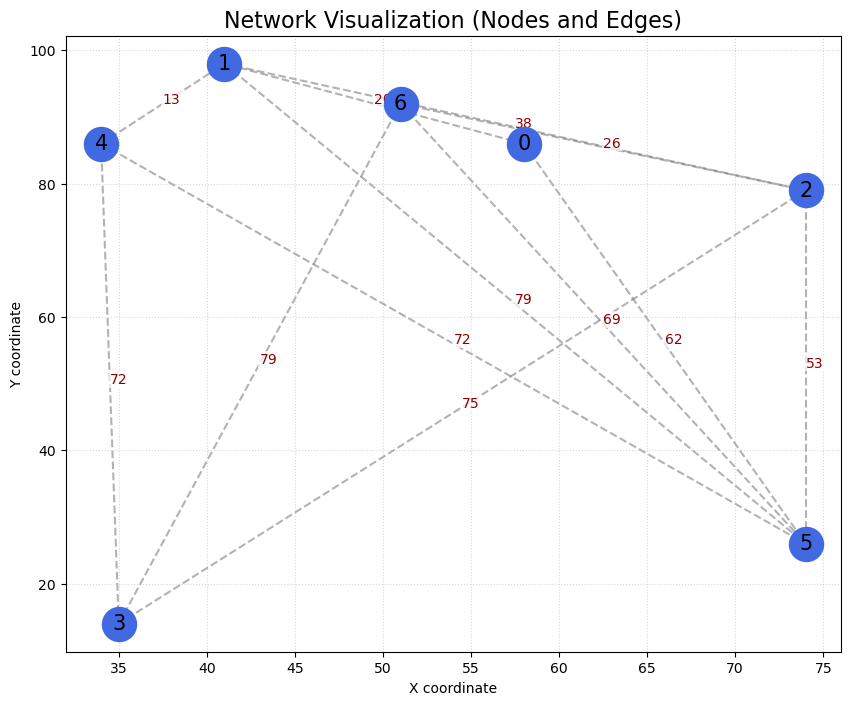

In [8]:
import matplotlib.pyplot as plt
from src.Map_visualize import map_visualize as mp
mp(map)

In [9]:
#　ランダムに変わるだろうが今回は0→1で行う 画像はoutput20260501
import numpy as np
import random
Q = np.zeros((num_node,num_node)) #Qテーブルをノード数の縦横で作る
start_node = 0
goal_node = 5 # ゴールノード設定

alpha = 0.1 #学習率
gamma = 0.9 #割引率
epsilon = 0.3 #e-greedy法で用いるQ値がいいものに行くかどうかの割合




In [10]:
import random

# ハイパーパラメータ
alpha = 0.1    # 学習率
gamma = 0.9    # 割引率
epsilon = 0.3  # 探索率（最初は高めでも良い）
nodes = map

def get_action(state, Q, epsilon):
    # 現在のノードから行ける隣接ノードのリストを取得
    available_edges = nodes[str(state)]['edges']
    next_nodes = [int(edge[0]) for edge in available_edges]
    
    if random.random() < epsilon:
        # 探索：ランダムに選択
        return random.choice(next_nodes)
    else:
        # 活用：Q値が最大のノードを選択（候補が複数ある場合はその中からランダム）
        q_values = [Q[state, n] for n in next_nodes]
        max_q = max(q_values)
        candidates = [n for n, q in zip(next_nodes, q_values) if q == max_q]
        return random.choice(candidates)

def update_q(state, next_state, reward, Q, alpha, gamma):
    # 次の状態での最大Q値を取得
    next_edges = nodes[str(next_state)]['edges']
    next_nodes = [int(edge[0]) for edge in next_edges]
    
    # ゴールの場合は次のQ値は0（終端のため）
    if next_state == goal_node:
        max_next_q = 0
    else:
        max_next_q = max([Q[next_state, n] for n in next_nodes])
    
    # Q値の更新式
    Q[state, next_state] = (1 - alpha) * Q[state, next_state] + \
                           alpha * (reward + gamma * max_next_q)

In [11]:
import random

# ハイパーパラメータ
alpha = 0.1    # 学習率
gamma = 0.9    # 割引率
epsilon = 0.3  # 探索率（最初は高めでも良い）

def get_action(state, Q, epsilon):
    # 現在のノードから行ける隣接ノードのリストを取得
    available_edges = nodes[str(state)]['edges']
    next_nodes = [int(edge[0]) for edge in available_edges]
    
    if random.random() < epsilon:
        # 探索：ランダムに選択
        return random.choice(next_nodes)
    else:
        # 活用：Q値が最大のノードを選択（候補が複数ある場合はその中からランダム）
        q_values = [Q[state, n] for n in next_nodes]
        max_q = max(q_values)
        candidates = [n for n, q in zip(next_nodes, q_values) if q == max_q]
        return random.choice(candidates)

def update_q(state, next_state, reward, Q, alpha, gamma):
    # 次の状態での最大Q値を取得
    next_edges = nodes[str(next_state)]['edges']
    next_nodes = [int(edge[0]) for edge in next_edges]
    
    # ゴールの場合は次のQ値は0（終端のため）
    if next_state == goal_node:
        max_next_q = 0
    else:
        max_next_q = max([Q[next_state, n] for n in next_nodes])
    
    # Q値の更新式
    Q[state, next_state] = (1 - alpha) * Q[state, next_state] + \
                           alpha * (reward + gamma * max_next_q)

In [12]:
# 学習の設定
num_episodes = 2000
max_steps_per_episode = 50 # 1回に動ける上限を決める
epsilon = 0.5 # 最初は高めに設定してしっかり探索させる

for episode in range(num_episodes):
    state = start_node
    
    for step in range(max_steps_per_episode):
        if state == goal_node:
            break
            
        # 1. 行動を選択
        next_state = get_action(state, Q, epsilon)
        
        # 2. 報酬を計算
        edge_weight = next(w for n, w in nodes[str(state)]['edges'] if int(n) == next_state)
        reward = -edge_weight
        if next_state == goal_node:
            reward += 1000 # ゴール報酬を大幅に増やして「やる気」を出させる
            
        # 3. Q値の更新
        update_q(state, next_state, reward, Q, alpha, gamma)
        
        # 4. 状態を更新
        state = next_state

    # 進行状況の表示
    if episode % 100 == 0:
        # epsilonを徐々に下げていく（徐々に賢い動きに固定する）
        epsilon *= 0.99 
        print(f"Episode: {episode}, Epsilon: {epsilon:.3f}")

print("学習完了！")

Episode: 0, Epsilon: 0.495
Episode: 100, Epsilon: 0.490
Episode: 200, Epsilon: 0.485
Episode: 300, Epsilon: 0.480
Episode: 400, Epsilon: 0.475
Episode: 500, Epsilon: 0.471
Episode: 600, Epsilon: 0.466
Episode: 700, Epsilon: 0.461
Episode: 800, Epsilon: 0.457
Episode: 900, Epsilon: 0.452
Episode: 1000, Epsilon: 0.448
Episode: 1100, Epsilon: 0.443
Episode: 1200, Epsilon: 0.439
Episode: 1300, Epsilon: 0.434
Episode: 1400, Epsilon: 0.430
Episode: 1500, Epsilon: 0.426
Episode: 1600, Epsilon: 0.421
Episode: 1700, Epsilon: 0.417
Episode: 1800, Epsilon: 0.413
Episode: 1900, Epsilon: 0.409
学習完了！


In [13]:
def extract_path(start, goal, Q):
    path = [start]
    current = start
    visited = set() # ループ防止用
    
    while current != goal:
        if current in visited: break
        visited.add(current)
        
        # Q値が最大のアクションを選択
        available_nodes = [int(e[0]) for e in nodes[str(current)]['edges']]
        q_values = {n: Q[current, n] for n in available_nodes}
        next_node = max(q_values, key=q_values.get)
        
        path.append(next_node)
        current = next_node
    return path

# ノード0からの最短経路を表示
best_path = extract_path(0, goal_node, Q)
print(f"ノード0から3への最適ルート: {best_path}")

ノード0から3への最適ルート: [0, 5]
